# UDL Assignment 1 – Group 76
## Representation Learning with Autoencoders

**Datasets:** CIFAR-10 (converted to grayscale) and MNIST  
**Image size:** 28×28 pixels  
**Intensity normalization:** [50, 200]  
**Split:** 70% train · 20% validation · 10% test

## Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import cifar10, mnist

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

2026-06-04 19:35:38.324685: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-04 19:35:38.326129: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-04 19:35:38.329570: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-04 19:35:38.339373: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780581938.356103   30081 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780581938.35

## Data Loading & Preprocessing

In [2]:
def preprocess_dataset(images, labels):
    """Resize to 28x28, convert to float, normalize to [50, 200]."""
    # Resize if needed (CIFAR-10 is 32x32)
    if images.shape[1] != 28:
        images = tf.image.resize(images[..., np.newaxis] if images.ndim == 3 else images,
                                 [28, 28]).numpy()
        images = images.squeeze(-1) if images.shape[-1] == 1 else images

    images = images.astype(np.float32)
    # Min-max scale to [50, 200]
    images = (images - images.min()) / (images.max() - images.min()) * 150 + 50
    return images, labels


def split_dataset(images, labels, seed=42):
    """70% train, 20% val, 10% test (stratified by shuffling)."""
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(images))
    n = len(images)
    train_end = int(0.7 * n)
    val_end   = int(0.9 * n)
    tr, va, te = idx[:train_end], idx[train_end:val_end], idx[val_end:]
    return (images[tr], labels[tr]), (images[va], labels[va]), (images[te], labels[te])


# ── CIFAR-10 ──────────────────────────────────────────────────────────────────
(c_tr_raw, c_tr_lbl), (c_te_raw, c_te_lbl) = cifar10.load_data()
c_all = np.concatenate([c_tr_raw, c_te_raw])
c_lbl = np.concatenate([c_tr_lbl, c_te_lbl]).flatten()

# Convert to grayscale
c_gray = np.dot(c_all[..., :3], [0.299, 0.587, 0.114])  # (N, 32, 32)

# Resize 32→28
c_gray_r = tf.image.resize(c_gray[..., np.newaxis], [28, 28]).numpy().squeeze(-1)
c_gray_r, c_lbl = preprocess_dataset(c_gray_r, c_lbl)

(c_train, c_train_lbl), (c_val, c_val_lbl), (c_test, c_test_lbl) = split_dataset(c_gray_r, c_lbl)

print(f"CIFAR-10  → train: {c_train.shape}, val: {c_val.shape}, test: {c_test.shape}")

# ── MNIST ─────────────────────────────────────────────────────────────────────
(m_tr_raw, m_tr_lbl), (m_te_raw, m_te_lbl) = mnist.load_data()
m_all = np.concatenate([m_tr_raw, m_te_raw]).astype(np.float32)
m_lbl = np.concatenate([m_tr_lbl, m_te_lbl])

m_all, m_lbl = preprocess_dataset(m_all, m_lbl)

(m_train, m_train_lbl), (m_val, m_val_lbl), (m_test, m_test_lbl) = split_dataset(m_all, m_lbl)

print(f"MNIST     → train: {m_train.shape}, val: {m_val.shape}, test: {m_test.shape}")

2026-06-04 19:35:42.483476: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


CIFAR-10  → train: (42000, 28, 28), val: (12000, 28, 28), test: (6000, 28, 28)
MNIST     → train: (49000, 28, 28), val: (14000, 28, 28), test: (7000, 28, 28)


---
## Task 1 – PCA, Logistic Regression, ROC Curves & SNR

1. Standard PCA with 70 % of training data → top-30 principal components  
2. Logistic Regression classifier on PCA features → ROC curves on test set  
3. Repeat with Randomized PCA and compare  
4. Average Signal-to-Noise Ratio (SNR) of reconstructed test images in dB


────────────────────────────────────────────────────────────
CIFAR-10 | Standard PCA
────────────────────────────────────────────────────────────
Test accuracy: 0.2983


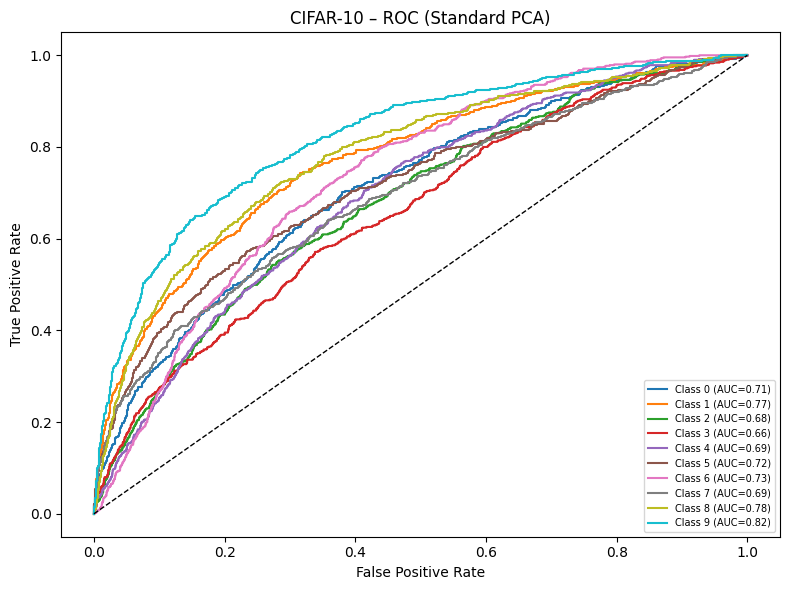

Mean AUC: 0.7261
Average SNR (dB): 20.0079

────────────────────────────────────────────────────────────
CIFAR-10 | Randomized PCA
────────────────────────────────────────────────────────────
Test accuracy: 0.2978


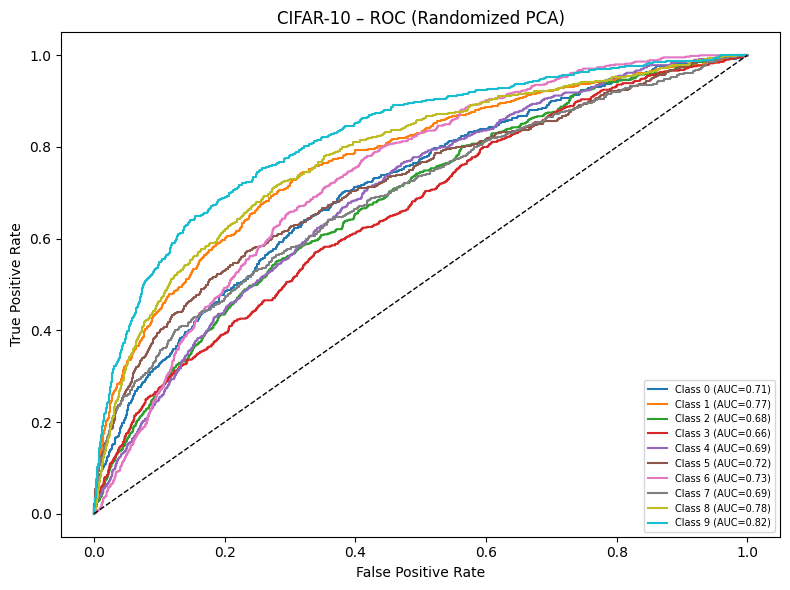

Mean AUC: 0.7262
Average SNR (dB): 20.0081

CIFAR-10 SNR comparison: Standard=20.01 dB | Randomized=20.01 dB

────────────────────────────────────────────────────────────
MNIST | Standard PCA
────────────────────────────────────────────────────────────
Test accuracy: 0.8813


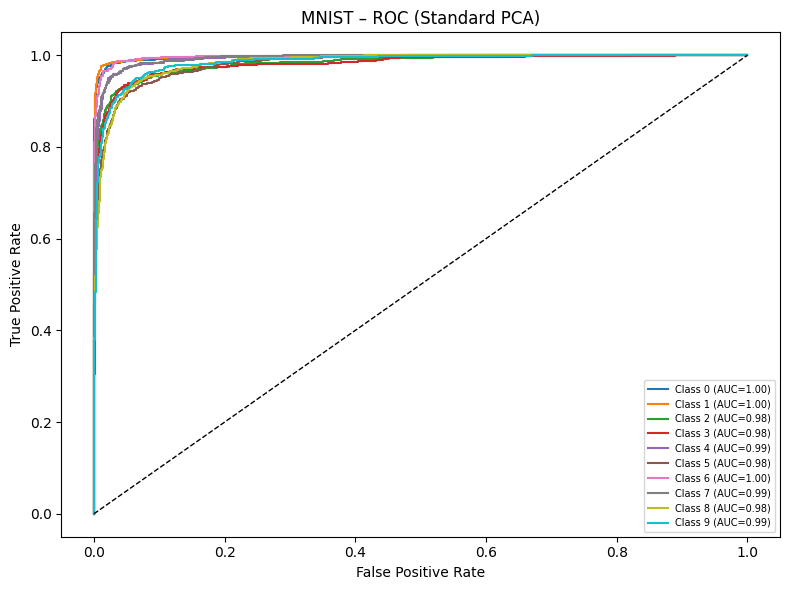

Mean AUC: 0.9892
Average SNR (dB): 11.2485

────────────────────────────────────────────────────────────
MNIST | Randomized PCA
────────────────────────────────────────────────────────────
Test accuracy: 0.8814


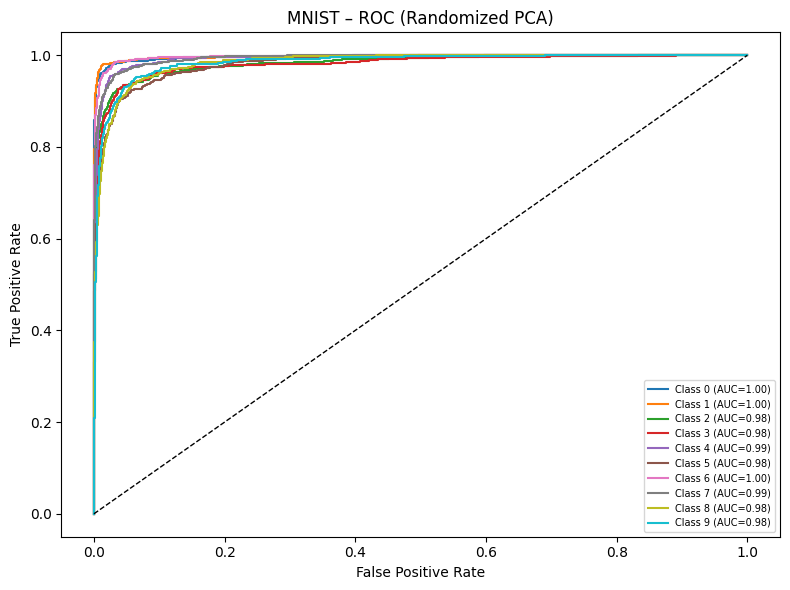

Mean AUC: 0.9891
Average SNR (dB): 11.2548

MNIST SNR comparison: Standard=11.25 dB | Randomized=11.25 dB


In [3]:
def flatten_and_normalize(images):
    """Flatten to (N, 784) and zero-mean / unit-variance per feature."""
    flat = images.reshape(len(images), -1)
    mean = flat.mean(axis=0)
    std  = flat.std(axis=0) + 1e-8
    return (flat - mean) / std, mean, std


def snr_db(original, reconstructed):
    """Average SNR in dB over a batch of images."""
    signal_power = np.mean(original ** 2, axis=1)
    noise_power  = np.mean((original - reconstructed) ** 2, axis=1) + 1e-10
    return np.mean(10 * np.log10(signal_power / noise_power))


def plot_roc_curves(y_true, y_score, n_classes, title):
    y_bin = label_binarize(y_true, classes=np.arange(n_classes))
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
    for i, c in enumerate(colors):
        plt.plot(fpr[i], tpr[i], color=c, lw=1.5,
                 label=f'Class {i} (AUC={roc_auc[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(title); plt.legend(loc='lower right', fontsize=7)
    plt.tight_layout(); plt.show()
    return np.mean(list(roc_auc.values()))


def run_pca_task(name, train_images, train_labels,
                 test_images, test_labels, n_components=30, randomized=False):
    print(f"\n{'─'*60}")
    print(f"{name} | {'Randomized' if randomized else 'Standard'} PCA")
    print(f"{'─'*60}")

    # Use 70% of training data for PCA fitting
    n_pca = int(0.7 * len(train_images))
    pca_fit_imgs = train_images[:n_pca]

    flat_fit, mean, std = flatten_and_normalize(pca_fit_imgs)
    flat_train = (train_images.reshape(len(train_images), -1) - mean) / std
    flat_test  = (test_images.reshape(len(test_images), -1)  - mean) / std

    svd = 'randomized' if randomized else 'full'
    pca = PCA(n_components=n_components, svd_solver=svd, random_state=42)
    pca.fit(flat_fit)

    # Project
    Z_train = pca.transform(flat_train)
    Z_test  = pca.transform(flat_test)

    # Logistic Regression
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(Z_train, train_labels)
    acc = clf.score(Z_test, test_labels)
    print(f"Test accuracy: {acc:.4f}")

    y_score = clf.predict_proba(Z_test)
    mean_auc = plot_roc_curves(test_labels, y_score, 10,
                               f"{name} – ROC ({'Randomized' if randomized else 'Standard'} PCA)")
    print(f"Mean AUC: {mean_auc:.4f}")

    # SNR of reconstructed test images
    recon_test = pca.inverse_transform(Z_test) * std + mean
    orig_flat  = test_images.reshape(len(test_images), -1)
    snr = snr_db(orig_flat, recon_test)
    print(f"Average SNR (dB): {snr:.4f}")

    return pca, clf, snr


# ── Run for both datasets ─────────────────────────────────────────────────────
results_t1 = {}

for ds_name, tr_imgs, tr_lbl, te_imgs, te_lbl in [
    ('CIFAR-10', c_train, c_train_lbl, c_test, c_test_lbl),
    ('MNIST',    m_train, m_train_lbl, m_test, m_test_lbl),
]:
    pca_std, clf_std, snr_std = run_pca_task(ds_name, tr_imgs, tr_lbl, te_imgs, te_lbl,
                                              randomized=False)
    pca_rnd, clf_rnd, snr_rnd = run_pca_task(ds_name, tr_imgs, tr_lbl, te_imgs, te_lbl,
                                              randomized=True)
    results_t1[ds_name] = dict(pca_std=pca_std, pca_rnd=pca_rnd,
                                snr_std=snr_std, snr_rnd=snr_rnd)
    print(f"\n{ds_name} SNR comparison: Standard={snr_std:.2f} dB | Randomized={snr_rnd:.2f} dB")

---
## Task 2 – Constrained Single-Layer Autoencoder (30 nodes, Linear)

- Encoder and decoder weight matrices are transposes of each other  
- Each weight vector has unit magnitude (tied, normalized weights)  
- Input: mean- and variance-normalized images  
- Compare learned weight vectors with PCA eigenvectors  
- Train Logistic Regression on the encoded features and compare with Task 1


Task 2 - CIFAR-10


2026-06-04 19:35:55.110129: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-04 19:35:55.460189: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-04 19:35:56.125616: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-04 19:35:57.444188: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Epoch  10 | train=0.1557 | val=0.1563


2026-06-04 19:36:00.053692: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Epoch  20 | train=0.1556 | val=0.1562
  Epoch  30 | train=0.1555 | val=0.1560


2026-06-04 19:36:05.279355: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Epoch  40 | train=0.1556 | val=0.1560
  Epoch  50 | train=0.1555 | val=0.1559
CIFAR-10 TiedAE training complete.


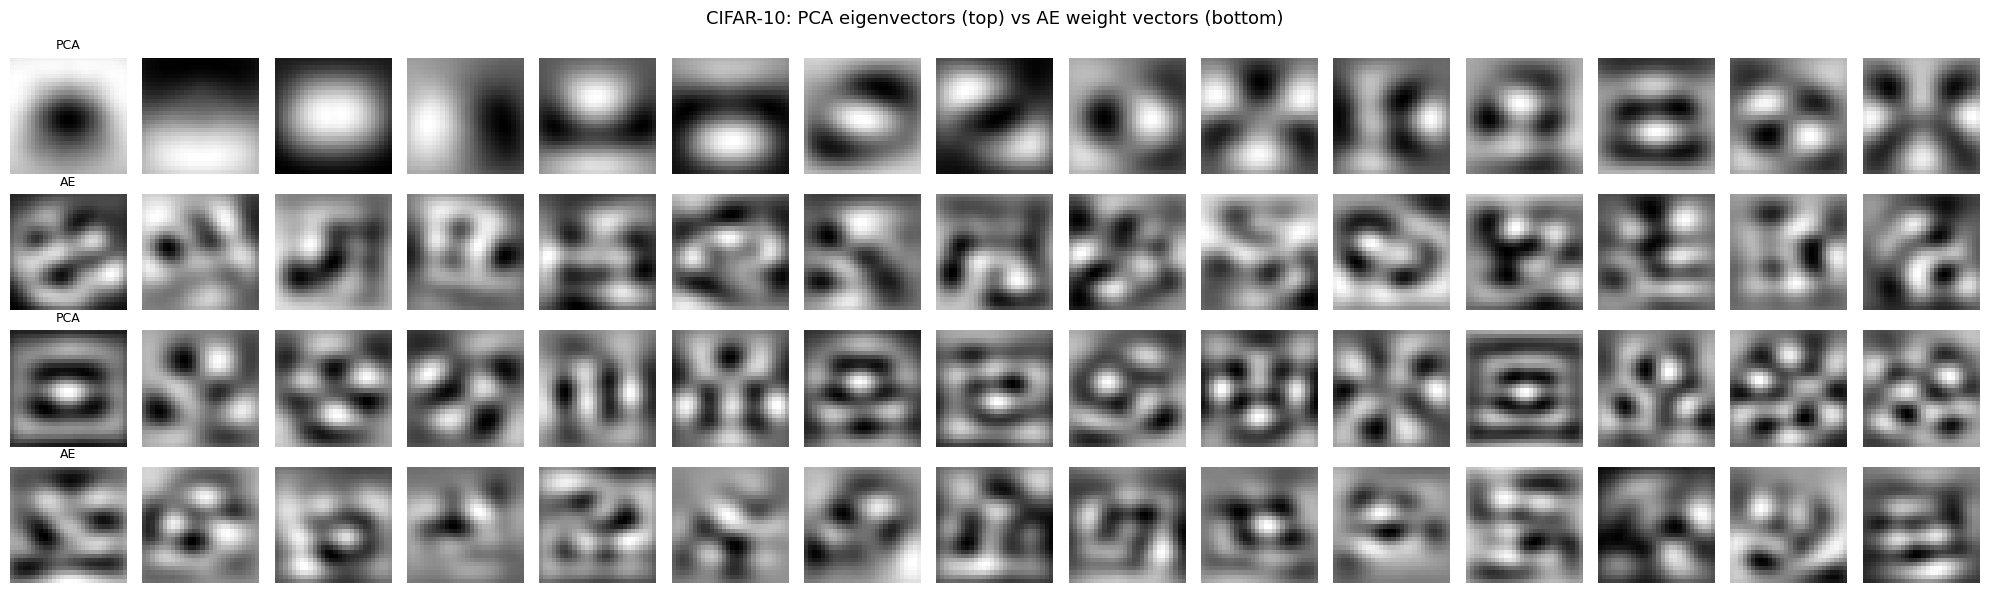

CIFAR-10: Mean max cosine similarity PCA↔AE = 0.4288
CIFAR-10 AE LR test accuracy: 0.2977

Task 2 - MNIST
  Epoch  10 | train=0.4909 | val=4808226373632.0000


2026-06-04 19:36:18.500919: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Epoch  20 | train=0.4900 | val=4808226373632.0000
  Epoch  30 | train=0.4897 | val=4808226373632.0000
  Epoch  40 | train=0.4919 | val=4808226373632.0000
  Epoch  50 | train=0.4895 | val=4808226373632.0000
MNIST TiedAE training complete.


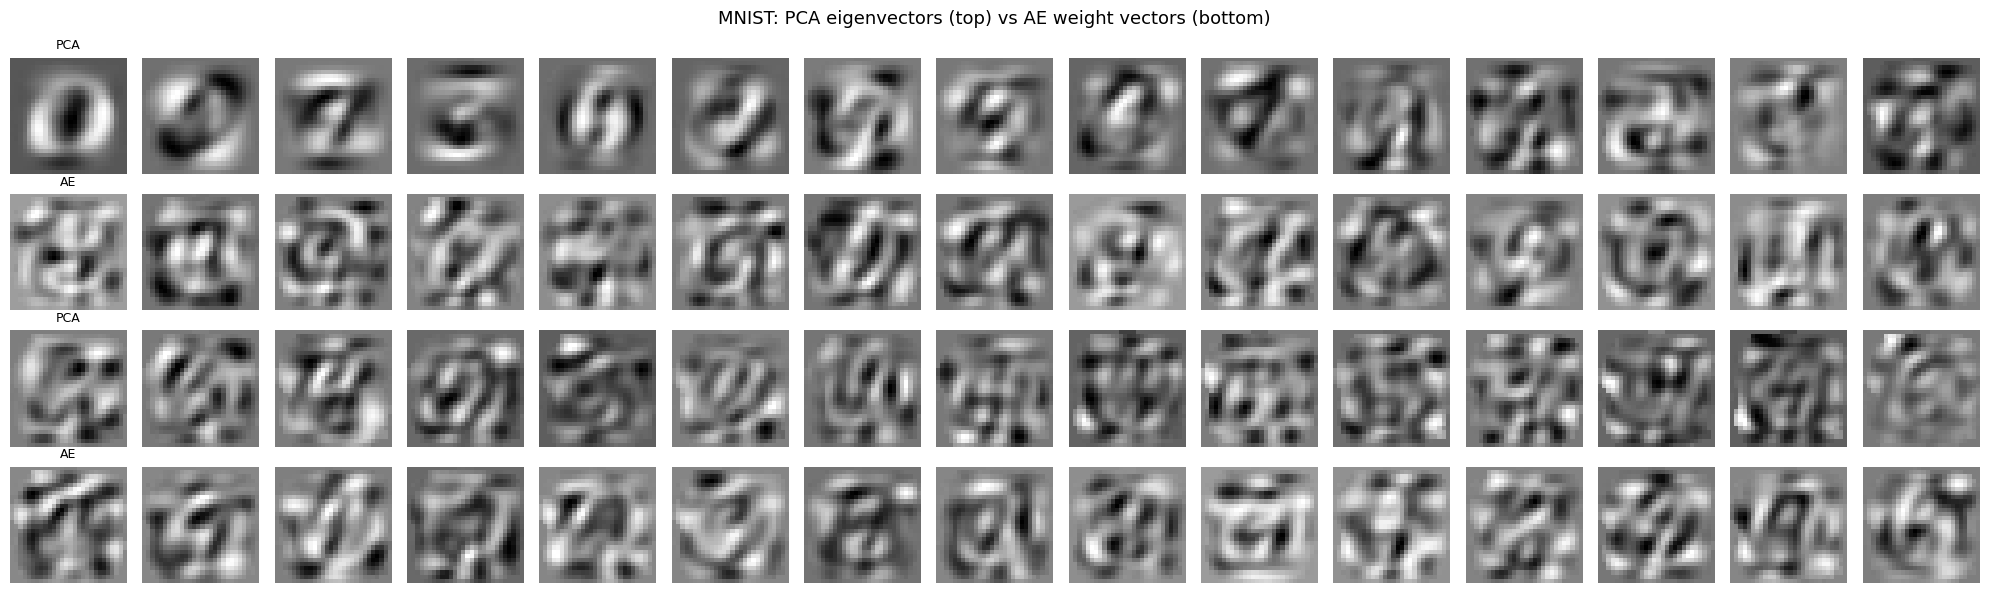

MNIST: Mean max cosine similarity PCA↔AE = 0.4360
MNIST AE LR test accuracy: 0.8816


In [4]:
class TiedAutoencoder(Model):
    """Single hidden layer AE with tied, unit-norm weights."""

    def __init__(self, input_dim, n_hidden=30):
        super().__init__()
        self.input_dim = input_dim
        self.n_hidden  = n_hidden
        # Encoder weight matrix W: shape (input_dim, n_hidden)
        self.W = self.add_weight(name='W',
                                  shape=(input_dim, n_hidden),
                                  initializer='glorot_uniform',
                                  trainable=True)
        self.b_enc = self.add_weight(name='b_enc', shape=(n_hidden,),
                                      initializer='zeros', trainable=True)
        self.b_dec = self.add_weight(name='b_dec', shape=(input_dim,),
                                      initializer='zeros', trainable=True)

    def _normed_W(self):
        """Normalize each column of W to unit L2 norm."""
        return self.W / (tf.norm(self.W, axis=0, keepdims=True) + 1e-8)

    def encode(self, x):
        W_n = self._normed_W()
        return x @ W_n + self.b_enc          # linear activation

    def decode(self, z):
        W_n = self._normed_W()
        return z @ tf.transpose(W_n) + self.b_dec  # tied: W^T

    def call(self, x):
        return self.decode(self.encode(x))


def train_tied_ae(name, train_images, val_images, n_hidden=30,
                  epochs=50, batch_size=256):
    flat_tr, mean, std = flatten_and_normalize(train_images)
    flat_va = (val_images.reshape(len(val_images), -1) - mean) / std

    input_dim = flat_tr.shape[1]
    ae = TiedAutoencoder(input_dim, n_hidden)

    optimizer = keras.optimizers.Adam(1e-3)
    loss_fn   = keras.losses.MeanSquaredError()

    ds_tr = (tf.data.Dataset
              .from_tensor_slices(flat_tr.astype(np.float32))
              .shuffle(10000).batch(batch_size))

    hist = {'train_loss': [], 'val_loss': []}

    @tf.function
    def train_step(x):
        with tf.GradientTape() as tape:
            loss = loss_fn(x, ae(x))
        grads = tape.gradient(loss, ae.trainable_variables)
        optimizer.apply_gradients(zip(grads, ae.trainable_variables))
        return loss

    for epoch in range(1, epochs + 1):
        epoch_loss = []
        for batch in ds_tr:
            epoch_loss.append(train_step(batch).numpy())
        val_loss = loss_fn(flat_va.astype(np.float32),
                           ae(flat_va.astype(np.float32))).numpy()
        hist['train_loss'].append(np.mean(epoch_loss))
        hist['val_loss'].append(val_loss)
        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d} | train={hist['train_loss'][-1]:.4f} "
                  f"| val={val_loss:.4f}")

    print(f"{name} TiedAE training complete.")
    return ae, mean, std, hist


def visualize_comparison(pca, ae, name, n_show=30):
    """Display PCA eigenvectors vs AE weight vectors as 28x28 grayscale images."""
    pca_vecs = pca.components_[:n_show]  # (30, 784)

    W_normed = ae._normed_W().numpy().T   # (30, 784)

    fig, axes = plt.subplots(4, 15, figsize=(20, 6))
    fig.suptitle(f"{name}: PCA eigenvectors (top) vs AE weight vectors (bottom)", fontsize=13)

    for i in range(n_show):
        row_pca = axes[i // 15 * 2]
        row_ae  = axes[i // 15 * 2 + 1]
        col     = i % 15

        row_pca[col].imshow(pca_vecs[i].reshape(28, 28), cmap='gray')
        row_pca[col].axis('off')
        row_ae[col].imshow(W_normed[i].reshape(28, 28), cmap='gray')
        row_ae[col].axis('off')

    axes[0][0].set_title('PCA', fontsize=9)
    axes[1][0].set_title('AE', fontsize=9)
    axes[2][0].set_title('PCA', fontsize=9)
    axes[3][0].set_title('AE', fontsize=9)
    plt.tight_layout(); plt.show()

    # Quantitative similarity: mean absolute cosine similarity
    cos_sim = np.abs(pca_vecs @ W_normed.T)  # (30, 30)
    max_cos = cos_sim.max(axis=1).mean()
    print(f"{name}: Mean max cosine similarity PCA↔AE = {max_cos:.4f}")
    return max_cos


# ── Train and compare ─────────────────────────────────────────────────────────
results_t2 = {}

for ds_name, tr_imgs, tr_lbl, va_imgs, va_lbl, te_imgs, te_lbl in [
    ('CIFAR-10', c_train, c_train_lbl, c_val, c_val_lbl, c_test, c_test_lbl),
    ('MNIST',    m_train, m_train_lbl, m_val, m_val_lbl, m_test, m_test_lbl),
]:
    print(f"\n{'='*60}")
    print(f"Task 2 - {ds_name}")
    print(f"{'='*60}")

    ae, ae_mean, ae_std, hist = train_tied_ae(ds_name, tr_imgs, va_imgs)

    # Visualize weight vectors vs eigenvectors
    cos_sim = visualize_comparison(results_t1[ds_name]['pca_std'], ae, ds_name)

    # Logistic regression on AE features
    flat_tr = (tr_imgs.reshape(len(tr_imgs), -1) - ae_mean) / ae_std
    flat_te = (te_imgs.reshape(len(te_imgs), -1) - ae_mean) / ae_std

    Z_tr = ae.encode(flat_tr.astype(np.float32)).numpy()
    Z_te = ae.encode(flat_te.astype(np.float32)).numpy()

    clf2 = LogisticRegression(max_iter=1000, random_state=42)
    clf2.fit(Z_tr, tr_lbl)
    acc2 = clf2.score(Z_te, te_lbl)
    print(f"{ds_name} AE LR test accuracy: {acc2:.4f}")

    results_t2[ds_name] = dict(ae=ae, mean=ae_mean, std=ae_std,
                                cos_sim=cos_sim, accuracy=acc2)

---
## Task 3 – Deep Convolutional Autoencoder & Multi-Layer AE Comparison

1. **Deep convolutional AE** with 30-dimensional latent space → SNR on test sets  
2. **Single hidden layer AE** (sigmoid encoder, linear decoder, 30 nodes) → SNR  
3. **3-hidden-layer AE** (nodes equally split, sigmoid encoder layers, linear decoder) → SNR

In [5]:
# ── 3a: Deep Convolutional Autoencoder ────────────────────────────────────────

def build_conv_ae(latent_dim=30):
    """Convolutional AE: encoder compresses 28x28→latent, decoder reconstructs."""
    # Encoder
    inp = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)   # 28x28x32
    x = layers.MaxPooling2D(2, padding='same')(x)                       # 14x14x32
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)     # 14x14x64
    x = layers.MaxPooling2D(2, padding='same')(x)                       # 7x7x64
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)    # 7x7x128
    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, name='latent')(x)

    # Decoder
    y = layers.Dense(7 * 7 * 128, activation='relu')(latent)
    y = layers.Reshape((7, 7, 128))(y)
    y = layers.Conv2DTranspose(64, 3, activation='relu', padding='same')(y)
    y = layers.UpSampling2D(2)(y)                                       # 14x14x64
    y = layers.Conv2DTranspose(32, 3, activation='relu', padding='same')(y)
    y = layers.UpSampling2D(2)(y)                                       # 28x28x32
    out = layers.Conv2DTranspose(1, 3, activation='linear', padding='same')(y)  # 28x28x1

    return Model(inp, out, name='ConvAE')


def train_keras_ae(model, train_imgs, val_imgs, epochs=50, batch_size=256):
    model.compile(optimizer='adam', loss='mse')
    history = model.fit(
        train_imgs, train_imgs,
        validation_data=(val_imgs, val_imgs),
        epochs=epochs, batch_size=batch_size, verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(
            patience=5, restore_best_weights=True, monitor='val_loss')]
    )
    return history


def compute_snr_keras(model, test_imgs):
    recon = model.predict(test_imgs, verbose=0)
    orig  = test_imgs.reshape(len(test_imgs), -1)
    rec   = recon.reshape(len(recon), -1)
    return snr_db(orig, rec)


# Prepare 4D tensors (N, 28, 28, 1) normalized to [0,1] for Conv models
def to_4d(imgs):
    return (imgs / 200.0)[..., np.newaxis].astype(np.float32)


# ── 3b: Single hidden layer AE (sigmoid encoder, linear decoder, 30 nodes) ───

def build_shallow_ae(input_dim, n_hidden=30):
    inp = keras.Input(shape=(input_dim,))
    z   = layers.Dense(n_hidden, activation='sigmoid')(inp)
    out = layers.Dense(input_dim, activation='linear')(z)
    return Model(inp, out, name='ShallowAE')


# ── 3c: 3-hidden-layer AE (10 nodes each, sigmoid encoder, linear final) ─────

def build_deep_dense_ae(input_dim, n_hidden=30, n_layers=3):
    nodes_per_layer = n_hidden // n_layers   # 10 each
    inp = keras.Input(shape=(input_dim,))
    x = inp
    # Encoder: 3 sigmoid layers
    for _ in range(n_layers):
        x = layers.Dense(nodes_per_layer, activation='sigmoid')(x)
    # Decoder: mirror
    for _ in range(n_layers - 1):
        x = layers.Dense(nodes_per_layer * (n_layers - _), activation='sigmoid')(x)
    out = layers.Dense(input_dim, activation='linear')(x)
    return Model(inp, out, name='DeepDenseAE')


# ── Train and evaluate ────────────────────────────────────────────────────────
results_t3 = {}

for ds_name, tr_imgs, va_imgs, te_imgs in [
    ('CIFAR-10', c_train, c_val, c_test),
    ('MNIST',    m_train, m_val, m_test),
]:
    print(f"\n{'='*60}")
    print(f"Task 3 - {ds_name}")
    print(f"{'='*60}")

    input_dim = 28 * 28

    # ─ Conv AE ─
    conv_ae = build_conv_ae(latent_dim=30)
    conv_ae.summary()
    tr4, va4, te4 = to_4d(tr_imgs), to_4d(va_imgs), to_4d(te_imgs)
    train_keras_ae(conv_ae, tr4, va4, epochs=50)
    snr_conv = compute_snr_keras(conv_ae, te4)
    print(f"Conv AE SNR: {snr_conv:.4f} dB")

    # Normalize flat inputs for dense AEs
    flat_tr, mn, sd = flatten_and_normalize(tr_imgs)
    flat_va = (va_imgs.reshape(len(va_imgs), -1) - mn) / sd
    flat_te = (te_imgs.reshape(len(te_imgs), -1) - mn) / sd

    flat_tr = flat_tr.astype(np.float32)
    flat_va = flat_va.astype(np.float32)
    flat_te = flat_te.astype(np.float32)

    # ─ Shallow AE ─
    shallow_ae = build_shallow_ae(input_dim, n_hidden=30)
    shallow_ae.compile(optimizer='adam', loss='mse')
    shallow_ae.fit(flat_tr, flat_tr,
                   validation_data=(flat_va, flat_va),
                   epochs=50, batch_size=256, verbose=0,
                   callbacks=[keras.callbacks.EarlyStopping(
                       patience=5, restore_best_weights=True)])
    snr_shallow = snr_db(flat_te, shallow_ae.predict(flat_te, verbose=0))
    print(f"Shallow AE (sigmoid encoder / linear decoder) SNR: {snr_shallow:.4f} dB")

    # ─ Deep Dense AE ─
    deep_ae = build_deep_dense_ae(input_dim, n_hidden=30, n_layers=3)
    deep_ae.compile(optimizer='adam', loss='mse')
    deep_ae.fit(flat_tr, flat_tr,
                validation_data=(flat_va, flat_va),
                epochs=50, batch_size=256, verbose=0,
                callbacks=[keras.callbacks.EarlyStopping(
                    patience=5, restore_best_weights=True)])
    snr_deep = snr_db(flat_te, deep_ae.predict(flat_te, verbose=0))
    print(f"Deep Dense AE (3x10 nodes, sigmoid/linear) SNR: {snr_deep:.4f} dB")

    results_t3[ds_name] = dict(snr_conv=snr_conv,
                                snr_shallow=snr_shallow,
                                snr_deep=snr_deep)


Task 3 - CIFAR-10


Model: "ConvAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 30)             │       188,190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6272)           │       194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 64)       │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,839 (2.17 MB)

 Trainable params: 567,839 (2.17 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 30)             │       188,190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6272)           │       194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 7, 7, 64)       │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 14, 14, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,839 (2.17 MB)

 Trainable params: 567,839 (2.17 MB)

 Non-trainable params: 0 (0.00 B)

Conv AE SNR: 18.8762 dB
Shallow AE (sigmoid encoder / linear decoder) SNR: 1.8123 dB
Deep Dense AE (3x10 nodes, sigmoid/linear) SNR: -0.0027 dB


---
## Summary of Results

In [6]:
print(f"{'Dataset':<12} {'Task/Model':<45} {'SNR (dB)':>10}")
print('─' * 70)

for ds in ['CIFAR-10', 'MNIST']:
    r1 = results_t1[ds]
    r3 = results_t3[ds]
    print(f"{ds:<12} {'Task 1 - Standard PCA (30 PCs)':<45} {r1['snr_std']:>10.2f}")
    print(f"{ds:<12} {'Task 1 - Randomized PCA (30 PCs)':<45} {r1['snr_rnd']:>10.2f}")
    print(f"{ds:<12} {'Task 3 - Shallow AE (30, sigmoid/linear)':<45} {r3['snr_shallow']:>10.2f}")
    print(f"{ds:<12} {'Task 3 - Deep Dense AE (3x10, sigmoid/linear)':<45} {r3['snr_deep']:>10.2f}")
    print(f"{ds:<12} {'Task 3 - Conv AE (latent=30)':<45} {r3['snr_conv']:>10.2f}")
    print('─' * 70)

Dataset      Task/Model                                      SNR (dB)
──────────────────────────────────────────────────────────────────────
CIFAR-10     Task 1 - Standard PCA (30 PCs)                     20.01
CIFAR-10     Task 1 - Randomized PCA (30 PCs)                   20.01
CIFAR-10     Task 3 - Shallow AE (30, sigmoid/linear)            7.79
CIFAR-10     Task 3 - Deep Dense AE (3x10, sigmoid/linear)       2.47
CIFAR-10     Task 3 - Conv AE (latent=30)                       20.23
──────────────────────────────────────────────────────────────────────
MNIST        Task 1 - Standard PCA (30 PCs)                     11.25
MNIST        Task 1 - Randomized PCA (30 PCs)                   11.25
MNIST        Task 3 - Shallow AE (30, sigmoid/linear)            1.81
MNIST        Task 3 - Deep Dense AE (3x10, sigmoid/linear)      -0.00
MNIST        Task 3 - Conv AE (latent=30)                       18.88
──────────────────────────────────────────────────────────────────────


In [7]:
# Display system information
import platform
import sys
from datetime import datetime
# To get User information
import getpass
import torch

print("ENVIRONMENT INFORMATION")
print("\n  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab")
print("showing your account details in the cell below this one.")

# include the screen shot here
print("="*40)
print("   ENVIRONMENT CONFIGURATION REPORT")
print("="*40)

# User Identification (Auto-Detected)
print(f"System User:    {getpass.getuser()}")

# System Information
print(f"OS System:      {platform.system()} {platform.release()}")
print(f"Machine:        {platform.machine()}")
print(f"Python Version: {sys.version.split()[0]}")

# Deep Learning Configuration
print("-" * 40)
print(f"PyTorch Ver:    {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name:       {torch.cuda.get_device_name(0)}")
    print(f"GPU Count:      {torch.cuda.device_count()}")
else:
    print("GPU Name:       None (Running on CPU)")

# Key Library Versions
print("-" * 40)
print(f"NumPy:          {np.__version__}")
print("="*40)

ENVIRONMENT INFORMATION

  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab
showing your account details in the cell below this one.
   ENVIRONMENT CONFIGURATION REPORT
System User:    cloud
OS System:      Linux 5.14.0-503.31.1.el9_5.x86_64
Machine:        x86_64
Python Version: 3.9.21
----------------------------------------
PyTorch Ver:    2.6.0+cpu
CUDA Available: False
GPU Name:       None (Running on CPU)
----------------------------------------
NumPy:          2.0.2
